<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/05_3_transfer_learning_creating_and_exploring_a_vgg16_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification
This code compares the performance of a custom-built Convolutional Neural Network (CNN) with a fine-tuned VGG16 model for image classification. This code utilizes the tf_flowers dataset, which is well-suited for the VGG16 architecture.

## Flow of the Code
- **Dataset**: tf_flowers from the TensorFlow Datasets library. It consists of 5 different classes of flowers.

- **CNN from Scratch**: A sequential CNN model with multiple convolutional and pooling layers, followed by dense layers for classification.

- **Transfer Learning with VGG16**: Utilizes the pre-trained VGG16 model with weights from ImageNet. The base layers are frozen to leverage learned features, and new custom layers are added and trained on the flower dataset.

- **Fine-Tuning for Maximum Performance**: To enhance the VGG16 model's performance, a portion of the top layers of the base model are unfrozen and trained with a low learning rate. This allows the model to adapt its learned features more specifically to the new dataset.

- **Performance Comparison**: The training and validation accuracy and loss of both models are plotted on the same graphs for a clear and direct comparison.

## Dataset Loading and Preprocessing
- The tf_flowers dataset is loaded from tensorflow_datasets.

- It is split into training, validation, and test sets.

- A preprocess function resizes the images to 224x224 (the required input size for VGG16) and normalizes the pixel values to be between 0 and 1.

- The datasets are then batched and prefetched for efficient training.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# 1. Load and Preprocess the Dataset (tf_flowers)
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

num_classes = metadata.features['label'].num_classes
image_size = (224, 224)
batch_size = 32

def preprocess(image, label):
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).cache().shuffle(1000).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(batch_size).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(batch_size).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.PHDIIX_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


## CNN from Scratch

- A simple CNN architecture is defined using tf.keras.Sequential. It consists of three convolutional blocks with increasing filter sizes, each followed by a max-pooling layer to downsample the feature maps.

- A Flatten layer converts the 2D feature maps into a 1D vector.

- Two Dense layers act as the classifier, with the final layer having a softmax activation function for multi-class classification.

- The model is compiled with the adam optimizer and sparse_categorical_crossentropy loss function, which is suitable for integer-encoded labels.

In [2]:
# 2. Build and Train the CNN Model from Scratch
def build_scratch_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

scratch_model = build_scratch_model()
scratch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Training CNN from Scratch ---")
history_scratch = scratch_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
)

--- Training CNN from Scratch ---
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.3033 - loss: 2.6724 - val_accuracy: 0.4986 - val_loss: 1.2574
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.5080 - loss: 1.1980 - val_accuracy: 0.5422 - val_loss: 1.1271
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.6208 - loss: 0.9731 - val_accuracy: 0.5940 - val_loss: 1.0617
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.7439 - loss: 0.6997 - val_accuracy: 0.6267 - val_loss: 1.0322
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8463 - loss: 0.4268 - val_accuracy: 0.6131 - val_loss: 1.2340
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.9274 - loss: 0.2142 - val_accuracy: 0.6512 - val_loss: 1.4501
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9730 - loss: 0.1052 - val_accuracy: 0.5858 - val_loss: 2.1234
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9609 - los

## VGG16 Transfer Learning and Fine-Tuning

- The VGG16 model is instantiated from tf.keras.applications, with include_top=False to exclude the original classification layers. weights='imagenet' loads the pre-trained weights.

- base_model.trainable = False initially freezes all the layers of the VGG16 model.

- Crucially, the last four layers of the VGG16 base are set to be trainable (layer.trainable = True). This is the fine-tuning step, allowing the model to adjust its higher-level feature representations to the specifics of the flower dataset.

- A GlobalAveragePooling2D layer is added to reduce the spatial dimensions of the feature maps from the VGG16 base.

- A new classification head is added, consisting of a Dense layer with ReLU activation, a Dropout layer to prevent overfitting, and the final Dense output layer with softmax activation.

- The model is compiled with a very low learning rate (1e-5). This is important for fine-tuning to avoid "catastrophic forgetting" where the pre-trained weights are drastically altered.

In [3]:
# 3. Build and Train the VGG16 Transfer Learning Model
def build_transfer_model():
    base_model = tf.keras.applications.VGG16(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze the base_model
    base_model.trainable = False

    # Unfreeze some of the top layers for fine-tuning
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

transfer_model = build_transfer_model()
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Use a low learning rate for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Training with VGG16 Transfer Learning ---")
history_transfer = transfer_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
)


--- Training with VGG16 Transfer Learning ---
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 454ms/step - accuracy: 0.2781 - loss: 1.6045 - val_accuracy: 0.6730 - val_loss: 1.0353
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - accuracy: 0.6409 - loss: 0.9700 - val_accuracy: 0.7929 - val_loss: 0.6293
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 232ms/step - accuracy: 0.7799 - loss: 0.6368 - val_accuracy: 0.8174 - val_loss: 0.5184
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 235ms/step - accuracy: 0.7977 - loss: 0.5395 - val_accuracy: 0.8311 - val_loss: 0.4485
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.8470 - loss: 0.4278 - val_accuracy: 0.8420 - val_loss: 0.4705
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.8546 - loss: 0.4067 - val_accuracy: 0.8529 - val_loss: 0.4054
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.8870 - loss: 0.3390 - val_accuracy: 0.8474 - val_loss: 0.3957
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/st

## 4. Plot the Results
A helper function plot_history is defined to visualize the training and validation accuracy and loss for both models over the epochs. This provides a clear visual comparison of their learning progress and helps to identify overfitting.

Overfitting is evident when a model performs very well on the training data but poorly on the validation data — typically seen as:
- High training accuracy but low/stagnant/declining validation accuracy
- Low training loss but high/volatile validation loss

From the graphs, it can be clearly seen that the “CNN from Scratch” model is overfitting. In contrast, VGG16 Transfer Learning shows:
- Smaller gap between training and validation accuracy.
- Validation loss remains relatively low and stable.
- Indicates better generalization and less overfitting.


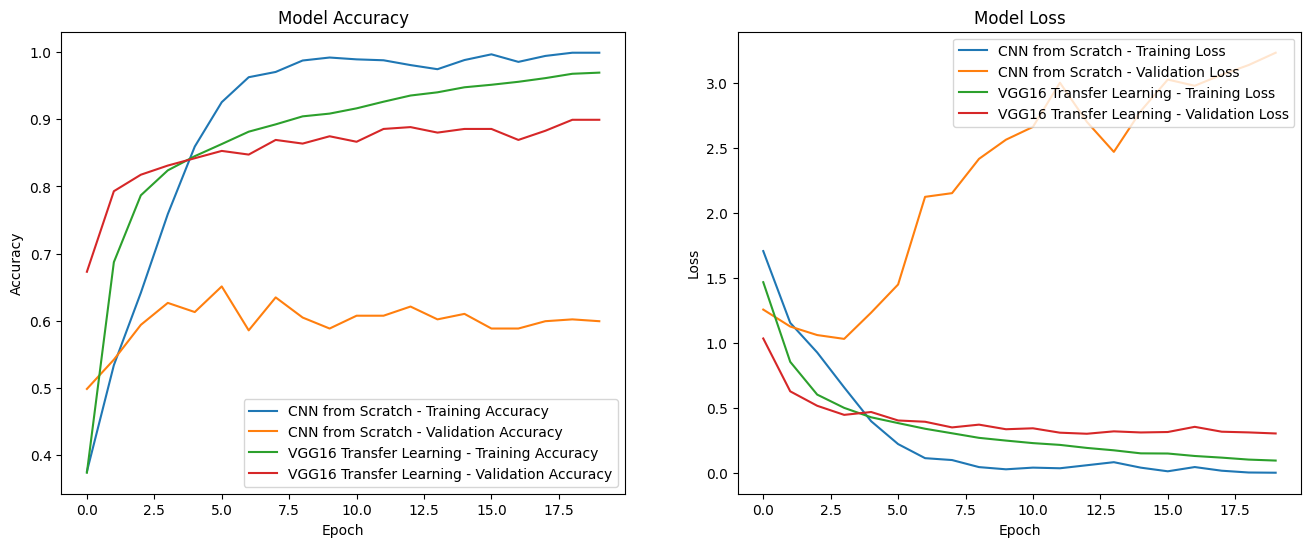

In [4]:
# 4. Plot the Results
def plot_history(history1, history2, title1, title2):
    plt.figure(figsize=(16, 6))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['accuracy'], label=f'{title1} - Training Accuracy')
    plt.plot(history1.history['val_accuracy'], label=f'{title1} - Validation Accuracy')
    plt.plot(history2.history['accuracy'], label=f'{title2} - Training Accuracy')
    plt.plot(history2.history['val_accuracy'], label=f'{title2} - Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history1.history['loss'], label=f'{title1} - Training Loss')
    plt.plot(history1.history['val_loss'], label=f'{title1} - Validation Loss')
    plt.plot(history2.history['loss'], label=f'{title2} - Training Loss')
    plt.plot(history2.history['val_loss'], label=f'{title2} - Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history_scratch, history_transfer, 'CNN from Scratch', 'VGG16 Transfer Learning')

## Evaluation

Finally, both the from-scratch model and the fine-tuned transfer learning model are evaluated on the unseen test dataset to provide a final, unbiased measure of their performance.

In [5]:
# 5. Evaluate on the Test Set
print("\n--- Evaluating CNN from Scratch on Test Data ---")
scratch_loss, scratch_accuracy = scratch_model.evaluate(test_ds)
print(f"Scratch Model - Test Accuracy: {scratch_accuracy:.4f}")

print("\n--- Evaluating VGG16 Transfer Learning Model on Test Data ---")
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_ds)
print(f"Transfer Learning Model - Test Accuracy: {transfer_accuracy:.4f}")


--- Evaluating CNN from Scratch on Test Data ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5524 - loss: 3.6466
Scratch Model - Test Accuracy: 0.5831

--- Evaluating VGG16 Transfer Learning Model on Test Data ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.8886 - loss: 0.2721
Transfer Learning Model - Test Accuracy: 0.9046


# Conclusions
- The CNN from scratch shows a slower learning curve and may struggle to achieve high accuracy on the validation set, potentially showing signs of overfitting.
- The VGG16 Transfer Learning model is expected to start with a much higher initial accuracy and converge faster.